# Uplifting 실습

Kaggle data 기반 Uplifting 실습
- Link : https://www.kaggle.com/datasets/davinwijaya/customer-retention

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Check 및 목표 설정

In [2]:
df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/datasets/marketing_promotion_uplifting.csv')
df

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
3,9,675.83,1,0,Rural,1,Web,Discount,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0
...,...,...,...,...,...,...,...,...,...
63995,10,105.54,1,0,Urban,0,Web,Discount,0
63996,5,38.91,0,1,Urban,1,Phone,Discount,0
63997,6,29.99,1,0,Urban,1,Phone,Discount,0
63998,1,552.94,1,0,Surburban,1,Multichannel,Buy One Get One,0


conversion을 전환으로 삼아도 될 것이다. 즉 conversion 변화를 예측하기로 하자

우선 변수를 정리해봅시다.
- recency : 가장 마지막 구매일로부터 지난 달 수
- history : 현재까지 총 구매액
- user_discount : 할인을 받은 적이 있는가? 있으면 1, 없으면 0
- user_bogo : 1+1을 받은 적이 있는가? (one get one 이 1+1)
- zip_code : 우편 번호 구분(지역 구분)
- is_referral : 추천 채널로부터 고객을 유입받은 것인지
- channel : 고객이 사용하는 채널
- offer : 고객에게 전송된 제안(마케팅/광고)
- conversion : 실제 전환 여부

### EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recency        64000 non-null  int64  
 1   history        64000 non-null  float64
 2   used_discount  64000 non-null  int64  
 3   used_bogo      64000 non-null  int64  
 4   zip_code       64000 non-null  object 
 5   is_referral    64000 non-null  int64  
 6   channel        64000 non-null  object 
 7   offer          64000 non-null  object 
 8   conversion     64000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 4.4+ MB


진짜 운좋게도 결측치가 없는 데이터

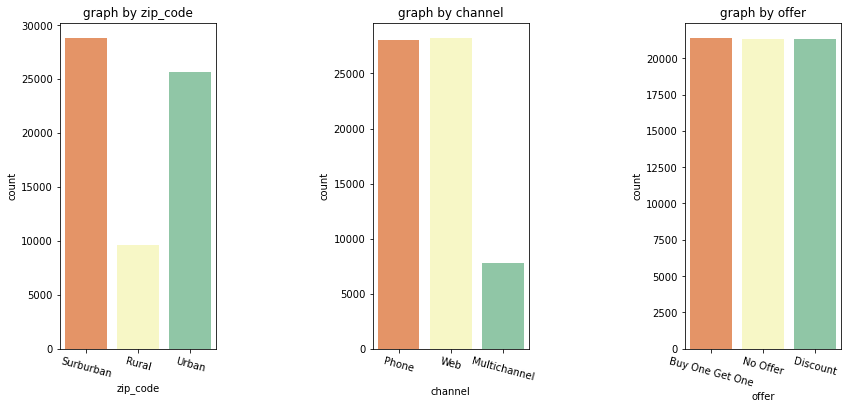

In [4]:
plt.figure(figsize = (14, 6))
columns = ['zip_code', 'channel', 'offer']
plt.subplots_adjust(wspace = 1)
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.title('graph by %s' % columns[i])
    plt.xticks(rotation = -15)
    sns.countplot(x = df[columns[i]], palette = "Spectral")

- Offer은 1:1:1 비율로 진행됨
- 웹, 핸드폰 단독 이요 유저가 다수
- 도시 및 근교 지역 거주 유저가 다수

### 문제 설정

BOGO(Buy One, Get One) Offer를 어떤 고객에게 하는 것이 합리적일지 Uplifting 모델링으로 찾아보기!

In [5]:
df

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
3,9,675.83,1,0,Rural,1,Web,Discount,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0
...,...,...,...,...,...,...,...,...,...
63995,10,105.54,1,0,Urban,0,Web,Discount,0
63996,5,38.91,0,1,Urban,1,Phone,Discount,0
63997,6,29.99,1,0,Urban,1,Phone,Discount,0
63998,1,552.94,1,0,Surburban,1,Multichannel,Buy One Get One,0


In [6]:
df_bogo_condi = df.offer.apply(lambda x: True if x in ['No Offer', 'Buy One Get One'] else False)
df_bogo = df.loc[df_bogo_condi]

## 학습

In [7]:
df_bogo

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0
5,6,134.83,0,1,Surburban,0,Phone,Buy One Get One,1
...,...,...,...,...,...,...,...,...,...
63989,10,304.30,1,1,Surburban,0,Web,Buy One Get One,1
63990,6,80.02,0,1,Surburban,0,Phone,No Offer,0
63991,1,306.10,1,0,Surburban,1,Phone,Buy One Get One,0
63993,4,374.07,0,1,Surburban,0,Phone,Buy One Get One,0


In [8]:
df_bogo = pd.get_dummies(df_bogo).drop('offer_No Offer', axis = 1)

In [9]:
df_bogo

,recency,history,used_discount,used_bogo,is_referral,conversion,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web,offer_Buy One Get One
0,10,142.44,1,0,0,0,0,1,0,0,1,0,1
1,6,329.08,1,1,1,0,1,0,0,0,0,1,0
2,7,180.65,0,1,1,0,0,1,0,0,0,1,1
4,2,45.34,1,0,0,0,0,0,1,0,0,1,1
5,6,134.83,0,1,0,1,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63989,10,304.30,1,1,0,1,0,1,0,0,0,1,1
63990,6,80.02,0,1,0,0,0,1,0,0,1,0,0
63991,1,306.10,1,0,1,0,0,1,0,0,1,0,1
63993,4,374.07,0,1,0,0,0,1,0,0,1,0,1


In [10]:
X = df_bogo.drop(['offer_Buy One Get One', 'conversion'], axis = 1)
y = df_bogo['conversion']
treatment = df_bogo['offer_Buy One Get One']

여기서 중요한 점은 실험군과 대조군을 나누는 정보를 따로 저장해야 모델 사용이 가능하다! 위에처럼 나눠준다.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(X, y, treatment, 
                                                                             test_size = 0.2, random_state = 42,
                                                                            stratify = df_bogo['offer_Buy One Get One'])

uplift를 위해서는 별도의 module 설치 필요

In [12]:
#!pip install scikit-uplift

In [13]:
from lightgbm import LGBMClassifier
from sklift.models import TwoModels
from sklift.viz import plot_uplift_preds

tm = TwoModels(
    estimator_trmnt = LGBMClassifier(objective='binary', metric='binary_logloss', max_depth=6),
    estimator_ctrl = LGBMClassifier(objective='binary', metric='binary_logloss', max_depth=6),
)

tm = tm.fit(X_train, y_train, treat_train)

trmnt는 처리군, ctrl은 대조군이 되겠다. estimator_trmnt

In [14]:
uplift_tm = tm.predict(X_test)

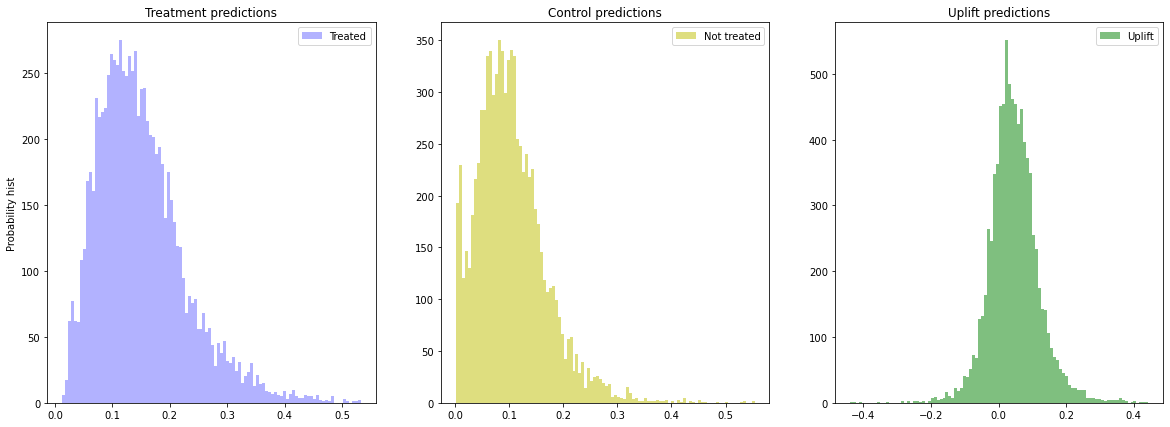

In [15]:
plot_uplift_preds(trmnt_preds=tm.trmnt_preds_, ctrl_preds=tm.ctrl_preds_);

이제 uplift 값이 일정 범위에 해당하는 유저들을 지정하면 될 것이다. 이 기준에 대해서는 확실하진 않으나, 광고 효과가 높은 유저를 찾기 위해서는 uplift 값이 일정 이상인 유저를 결정하는 것이 합리적일 것이다.

In [16]:
def get_segment(score):
    if score < -0.1: return 'Sleeping Dog' # 아예 부정적인 반응이 나올 유저들
    elif score < 0 : return 'Lost Causes' # 
    elif score < 0.1 : return 'Sure Things'
    else: return 'Persuadables'

In [17]:
user_seg_list = [get_segment(x) for x in uplift_tm]

In [18]:
print(user_seg_list.count('Persuadables') / len(user_seg_list))

0.18842955849631104


약 19% 정도의 유저만이 Persuadables에 해당된다. 모델의 정확도는 더 검토해야 하나, 간단하게 사용법을 확인하였다.
실제로 이렇게 할 경우 5배 정도의 예산 절감을 얻게 된다. 물론,지금은 베이스라인이라...

## 결과 추가 분석하기

이대로 끝내기는 솔직히 아쉽습니다.

In [21]:
X_result = X_test.copy()
X_result['segment'] = user_seg_list

예측 결과인 test를 가지고 한번 시각화를 진행시켜 어떤 의미가 있을지 조금만 더 만져봅시다.

In [22]:
X_result

,recency,history,used_discount,used_bogo,is_referral,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web,segment
52485,12,62.14,0,1,0,0,1,0,0,0,1,Sure Things
47157,5,300.48,0,1,0,0,1,0,0,1,0,Persuadables
25106,6,45.68,0,1,1,0,1,0,0,0,1,Sure Things
61162,5,202.56,1,0,1,0,0,1,1,0,0,Lost Causes
47704,5,521.94,0,1,1,0,0,1,0,1,0,Sure Things
...,...,...,...,...,...,...,...,...,...,...,...,...
13962,9,242.62,1,0,0,0,0,1,0,1,0,Sure Things
1706,9,140.51,1,0,0,0,1,0,0,1,0,Sure Things
16174,5,98.38,0,1,1,0,1,0,0,0,1,Persuadables
10074,1,77.94,1,0,1,1,0,0,0,1,0,Sure Things


<AxesSubplot:xlabel='recency', ylabel='segment'>

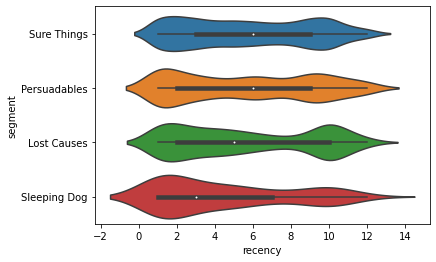

In [29]:
sns.violinplot(data = X_result, x = 'recency', y = 'segment')

<AxesSubplot:xlabel='history', ylabel='segment'>

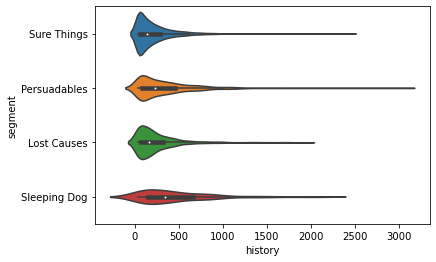

In [28]:
sns.violinplot(data = X_result, x = 'history', y = 'segment')

<AxesSubplot:xlabel='history', ylabel='recency'>

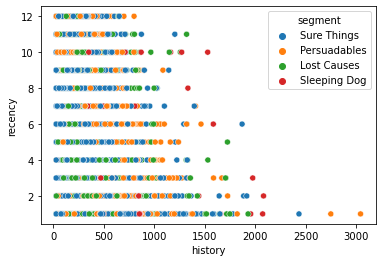

In [31]:
sns.scatterplot(data = X_result, x = 'history', y = 'recency', hue = 'segment')